In [19]:
!pip install -q onnxruntime panns_inference librosa soundfile matplotlib

In [20]:
import os
import glob
import time
import urllib.request
import numpy as np
import pandas as pd
import librosa
import librosa.display
import torch
import onnxruntime as ort
import matplotlib.pyplot as plt
from panns_inference import AudioTagging

from google.colab import drive
drive.mount('/content/drive')

search_pattern = '/content/drive/MyDrive/**/target_birds_manifest.csv'
manifest_files = glob.glob(search_pattern, recursive=True)

if manifest_files:
    manifest_path = manifest_files[0]
    base_dir = os.path.dirname(os.path.dirname(os.path.dirname(manifest_path)))
else:
    manifest_path = '/content/drive/MyDrive/TUGAS AKHIR/data/manifests/target_birds_manifest.csv'
    base_dir = '/content/drive/MyDrive/TUGAS AKHIR'

split_path = os.path.join(os.path.dirname(manifest_path), 'dataset_split.csv')
ckpt_dir = os.path.join(base_dir, "checkpoints")
if not os.path.exists(ckpt_dir):
    ckpt_dir = "/content/checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

results_proc_dir = os.path.join(base_dir, "results", "processed")
results_fig_dir = os.path.join(base_dir, "results", "figures")
os.makedirs(results_proc_dir, exist_ok=True)
os.makedirs(results_fig_dir, exist_ok=True)

print(f"[PATH] Root direktori       : {base_dir}")
print(f"[PATH] Folder model         : {ckpt_dir}")
print(f"[PATH] Direktori hasil CSV  : {results_proc_dir}")
print(f"[PATH] Direktori hasil Plot : {results_fig_dir}")

df_split = pd.read_csv(split_path)
df_split['split_role'] = df_split['split_role'].replace({'clean_query': 'query_clean'})

def resolve_path(rel_path):
    p1 = os.path.join(base_dir, rel_path)
    if os.path.exists(p1): return p1
    p2 = os.path.join(base_dir, "data", rel_path)
    if os.path.exists(p2): return p2
    return p1

df_split['full_path'] = df_split['file_path'].apply(resolve_path)
df_valid = df_split[df_split['full_path'].apply(os.path.exists)].copy().reset_index(drop=True)

gallery_df = df_valid[df_valid['split_role'] == 'gallery'].copy().reset_index(drop=True)
query_df   = df_valid[df_valid['split_role'] == 'query_clean'].copy().reset_index(drop=True)

print(f"[DATA] Rekaman Gallery : {len(gallery_df)} berkas ({gallery_df['species_key'].nunique()} spesies)")
print(f"[DATA] Rekaman Query   : {len(query_df)} berkas ({query_df['species_key'].nunique()} spesies)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[PATH] Root direktori       : /content/drive/MyDrive/TUGAS AKHIR
[PATH] Folder model         : /content/drive/MyDrive/TUGAS AKHIR/checkpoints
[PATH] Direktori hasil CSV  : /content/drive/MyDrive/TUGAS AKHIR/results/processed
[PATH] Direktori hasil Plot : /content/drive/MyDrive/TUGAS AKHIR/results/figures
[DATA] Rekaman Gallery : 136 berkas (14 spesies)
[DATA] Rekaman Query   : 14 berkas (14 spesies)


In [21]:
import os
import glob
import time
import urllib.request
import numpy as np
import pandas as pd
import librosa
import librosa.display
import torch
import onnxruntime as ort
import matplotlib.pyplot as plt
from panns_inference import AudioTagging

from google.colab import drive
drive.mount('/content/drive')

search_pattern = '/content/drive/MyDrive/**/target_birds_manifest.csv'
manifest_files = glob.glob(search_pattern, recursive=True)

if manifest_files:
    manifest_path = manifest_files[0]
    base_dir = os.path.dirname(os.path.dirname(os.path.dirname(manifest_path)))
else:
    manifest_path = '/content/drive/MyDrive/TUGAS AKHIR/data/manifests/target_birds_manifest.csv'
    base_dir = '/content/drive/MyDrive/TUGAS AKHIR'

split_path = os.path.join(os.path.dirname(manifest_path), 'dataset_split.csv')
ckpt_dir = os.path.join(base_dir, "checkpoints")
if not os.path.exists(ckpt_dir):
    ckpt_dir = "/content/checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

results_proc_dir = os.path.join(base_dir, "results", "processed")
results_fig_dir = os.path.join(base_dir, "results", "figures")
os.makedirs(results_proc_dir, exist_ok=True)
os.makedirs(results_fig_dir, exist_ok=True)

print(f"[PATH] Root direktori       : {base_dir}")
print(f"[PATH] Folder model         : {ckpt_dir}")
print(f"[PATH] Direktori hasil CSV  : {results_proc_dir}")
print(f"[PATH] Direktori hasil Plot : {results_fig_dir}")

df_split = pd.read_csv(split_path)
df_split['split_role'] = df_split['split_role'].replace({'clean_query': 'query_clean'})

def resolve_path(rel_path):
    p1 = os.path.join(base_dir, rel_path)
    if os.path.exists(p1): return p1
    p2 = os.path.join(base_dir, "data", rel_path)
    if os.path.exists(p2): return p2
    return p1

df_split['full_path'] = df_split['file_path'].apply(resolve_path)
df_valid = df_split[df_split['full_path'].apply(os.path.exists)].copy().reset_index(drop=True)

gallery_df = df_valid[df_valid['split_role'] == 'gallery'].copy().reset_index(drop=True)
query_df   = df_valid[df_valid['split_role'] == 'query_clean'].copy().reset_index(drop=True)

print(f"[DATA] Rekaman Gallery : {len(gallery_df)} berkas ({gallery_df['species_key'].nunique()} spesies)")
print(f"[DATA] Rekaman Query   : {len(query_df)} berkas ({query_df['species_key'].nunique()} spesies)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[PATH] Root direktori       : /content/drive/MyDrive/TUGAS AKHIR
[PATH] Folder model         : /content/drive/MyDrive/TUGAS AKHIR/checkpoints
[PATH] Direktori hasil CSV  : /content/drive/MyDrive/TUGAS AKHIR/results/processed
[PATH] Direktori hasil Plot : /content/drive/MyDrive/TUGAS AKHIR/results/figures
[DATA] Rekaman Gallery : 136 berkas (14 spesies)
[DATA] Rekaman Query   : 14 berkas (14 spesies)


In [22]:
TARGET_SR = 32000
DURATION_SEC = 5.0
TARGET_SAMPLES = int(TARGET_SR * DURATION_SEC) # 160.000 sampel
TARGET_RMS = 0.05

def preprocess_audio(path):
    y, sr = librosa.load(path, sr=TARGET_SR, mono=True)
    if len(y) > TARGET_SAMPLES:
        hop = TARGET_SAMPLES // 4
        num_windows = max(1, (len(y) - TARGET_SAMPLES) // hop + 1)
        best_rms, best_start = -1.0, 0
        for i in range(num_windows):
            seg = y[i*hop : i*hop + TARGET_SAMPLES]
            rms = np.sqrt(np.mean(seg**2))
            if rms > best_rms:
                best_rms = rms
                best_start = i*hop
        y = y[best_start : best_start + TARGET_SAMPLES]
    elif len(y) < TARGET_SAMPLES:
        y = np.pad(y, (0, TARGET_SAMPLES - len(y)), mode='constant')
    y = y[:TARGET_SAMPLES]

    current_rms = np.sqrt(np.mean(y**2))
    if current_rms > 1e-6:
        y = y * (TARGET_RMS / current_rms)
    return np.clip(y, -1.0, 1.0).astype(np.float32)


-------------------------------------------------------------------------------------
[BUKTI PRAPEMROSESAN] Mengaudit statistik prapemrosesan pada seluruh berkas...
-------------------------------------------------------------------------------------
[SAVE] Tabel verifikasi prapemrosesan disimpan ke: /content/drive/MyDrive/TUGAS AKHIR/results/processed/preprocessing_verification_table.csv

[RINGKASAN] STATISTIK PERUBAHAN SINYAL (SEBELUM VS SESUDAH PRAPEMROSESAN)
Parameter Sinyal             | Sebelum Prapemrosesan (Mentah) | Sesudah Prapemrosesan (Standar)
-------------------------------------------------------------------------------------
Laju Sampel (Sample Rate)    | 22050 - 48000 Hz (Variatif)      | 32000 Hz (Konstan)
Durasi Rekaman               | 2.5 - 188.3s (Rerata: 40.1s)    | 5.0 detik (Konstan / 160.000 sampel)
Energi RMS (Root Mean Sq)    | 0.0024 - 0.2796 (Rerata: 0.0588) | 0.0500 (+- 0.0004) (Tepat 0.05)
Puncak Amplitudo (Peak)      | 0.0377 - 1.2652 (Rerata: 0.5717) |

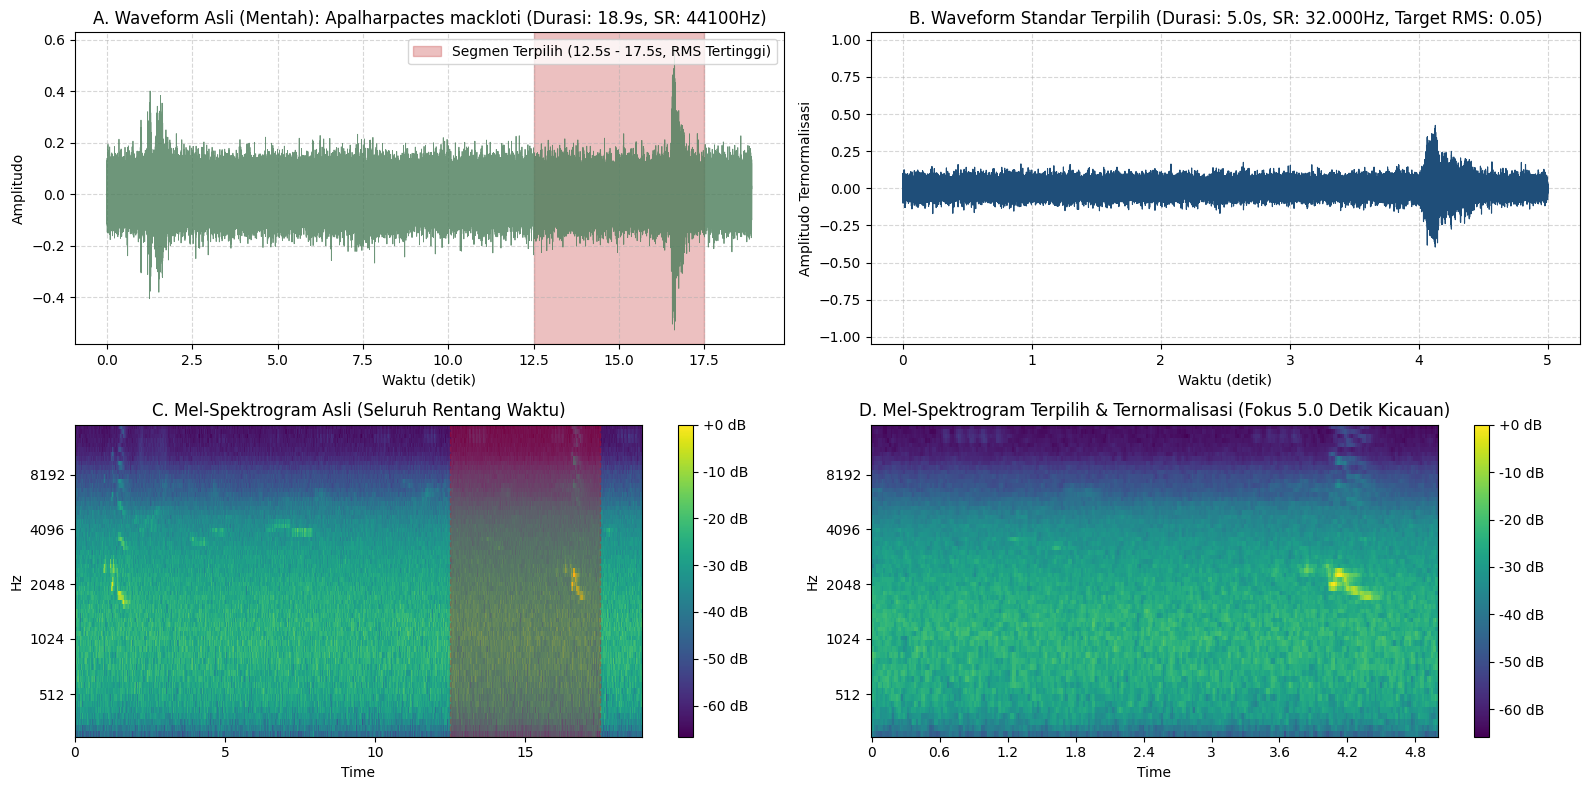

[SAVE] Gambar komparasi prapemrosesan disimpan ke: /content/drive/MyDrive/TUGAS AKHIR/results/figures/preprocessing_before_after_comparison.png


In [23]:
print("\n" + "-" * 85)
print("[BUKTI PRAPEMROSESAN] Mengaudit statistik prapemrosesan pada seluruh berkas...")
print("-" * 85)
audit_records = []
for idx, row in df_valid.iterrows():
    p = row['full_path']
    y_raw, sr_raw = librosa.load(p, sr=None, mono=False)
    dur_raw = len(y_raw) / sr_raw if y_raw.ndim == 1 else y_raw.shape[1] / sr_raw
    y_raw_mono = librosa.to_mono(y_raw) if y_raw.ndim > 1 else y_raw
    rms_raw = float(np.sqrt(np.mean(y_raw_mono ** 2)))
    peak_raw = float(np.max(np.abs(y_raw_mono)))

    y_proc = preprocess_audio(p)
    rms_proc = float(np.sqrt(np.mean(y_proc ** 2)))
    peak_proc = float(np.max(np.abs(y_proc)))

    audit_records.append({
        'id': row['id'],
        'species_key': row['species_key'],
        'split_role': row.get('split_role', 'gallery'),
        'sr_original': sr_raw,
        'sr_processed': TARGET_SR,
        'dur_original_sec': round(dur_raw, 2),
        'dur_processed_sec': DURATION_SEC,
        'rms_original': round(rms_raw, 4),
        'rms_processed': round(rms_proc, 4),
        'peak_original': round(peak_raw, 4),
        'peak_processed': round(peak_proc, 4)
    })
df_audit = pd.DataFrame(audit_records)
audit_csv_path = os.path.join(results_proc_dir, "preprocessing_verification_table.csv")
df_audit.to_csv(audit_csv_path, index=False)
print(f"[SAVE] Tabel verifikasi prapemrosesan disimpan ke: {audit_csv_path}")
print("\n" + "=" * 85)
print("[RINGKASAN] STATISTIK PERUBAHAN SINYAL (SEBELUM VS SESUDAH PRAPEMROSESAN)")
print("=" * 85)
print(f"{'Parameter Sinyal':<28} | {'Sebelum Prapemrosesan (Mentah)':<30} | {'Sesudah Prapemrosesan (Standar)':<30}")
print("-" * 85)
print(f"{'Laju Sampel (Sample Rate)':<28} | {df_audit['sr_original'].min()} - {df_audit['sr_original'].max()} Hz (Variatif)      | {TARGET_SR} Hz (Konstan)")
print(f"{'Durasi Rekaman':<28} | {df_audit['dur_original_sec'].min():.1f} - {df_audit['dur_original_sec'].max():.1f}s (Rerata: {df_audit['dur_original_sec'].mean():.1f}s)    | {DURATION_SEC} detik (Konstan / 160.000 sampel)")
print(f"{'Energi RMS (Root Mean Sq)':<28} | {df_audit['rms_original'].min():.4f} - {df_audit['rms_original'].max():.4f} (Rerata: {df_audit['rms_original'].mean():.4f}) | {df_audit['rms_processed'].mean():.4f} (+- {df_audit['rms_processed'].std():.4f}) (Tepat 0.05)")
print(f"{'Puncak Amplitudo (Peak)':<28} | {df_audit['peak_original'].min():.4f} - {df_audit['peak_original'].max():.4f} (Rerata: {df_audit['peak_original'].mean():.4f}) | {df_audit['peak_processed'].min():.4f} - {df_audit['peak_processed'].max():.4f} (Aman / Tidak Klip)")
print("=" * 85)
# Visualisasi Komparasi Grafis 4-Panel (Before vs After)
sample_case = df_valid[df_valid['species_key'] == 'Apalharpactes mackloti'].iloc[0]
raw_path = sample_case['full_path']
y_orig, sr_orig = librosa.load(raw_path, sr=None, mono=True)
dur_orig = len(y_orig) / sr_orig
t_orig = np.linspace(0, dur_orig, len(y_orig))
y_32k_samp = librosa.resample(y_orig, orig_sr=sr_orig, target_sr=TARGET_SR)
if len(y_32k_samp) > TARGET_SAMPLES:
    hop = TARGET_SAMPLES // 4
    num_windows = max(1, (len(y_32k_samp) - TARGET_SAMPLES) // hop + 1)
    best_rms, best_start = -1.0, 0
    for i in range(num_windows):
        seg = y_32k_samp[i*hop : i*hop + TARGET_SAMPLES]
        r = np.sqrt(np.mean(seg**2))
        if r > best_rms:
            best_rms = r
            best_start = i*hop
    sel_start_sec = best_start / TARGET_SR
    sel_end_sec = sel_start_sec + DURATION_SEC
else:
    sel_start_sec = 0.0
    sel_end_sec = dur_orig
y_final = preprocess_audio(raw_path)
t_final = np.linspace(0, DURATION_SEC, len(y_final))
fig, axs = plt.subplots(2, 2, figsize=(16, 8))
axs[0, 0].plot(t_orig, y_orig, color='#4a7c59', alpha=0.8, linewidth=0.6)
axs[0, 0].axvspan(sel_start_sec, sel_end_sec, color='#c94c4c', alpha=0.35,
                  label=f'Segmen Terpilih ({sel_start_sec:.1f}s - {sel_end_sec:.1f}s, RMS Tertinggi)')
axs[0, 0].set_title(f"A. Waveform Asli (Mentah): {sample_case['species_key']} (Durasi: {dur_orig:.1f}s, SR: {sr_orig}Hz)")
axs[0, 0].set_xlabel("Waktu (detik)")
axs[0, 0].set_ylabel("Amplitudo")
axs[0, 0].legend(loc='upper right')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)
axs[0, 1].plot(t_final, y_final, color='#1f4e79', linewidth=0.8)
axs[0, 1].set_title("B. Waveform Standar Terpilih (Durasi: 5.0s, SR: 32.000Hz, Target RMS: 0.05)")
axs[0, 1].set_xlabel("Waktu (detik)")
axs[0, 1].set_ylabel("Amplitudo Ternormalisasi")
axs[0, 1].set_ylim(-1.05, 1.05)
axs[0, 1].grid(True, linestyle='--', alpha=0.5)
S_orig = librosa.feature.melspectrogram(y=y_orig, sr=sr_orig, n_mels=64, fmin=150, fmax=15000)
S_orig_db = librosa.power_to_db(S_orig, ref=np.max)
img1 = librosa.display.specshow(S_orig_db, sr=sr_orig, x_axis='time', y_axis='mel', fmin=150, fmax=15000, ax=axs[1, 0], cmap='viridis')
axs[1, 0].axvspan(sel_start_sec, sel_end_sec, color='red', alpha=0.25, linestyle='--')
axs[1, 0].set_title("C. Mel-Spektrogram Asli (Seluruh Rentang Waktu)")
fig.colorbar(img1, ax=axs[1, 0], format="%+2.0f dB")
S_proc = librosa.feature.melspectrogram(y=y_final, sr=TARGET_SR, n_mels=64, fmin=150, fmax=15000)
S_proc_db = librosa.power_to_db(S_proc, ref=np.max)
img2 = librosa.display.specshow(S_proc_db, sr=TARGET_SR, x_axis='time', y_axis='mel', fmin=150, fmax=15000, ax=axs[1, 1], cmap='viridis')
axs[1, 1].set_title("D. Mel-Spektrogram Terpilih & Ternormalisasi (Fokus 5.0 Detik Kicauan)")
fig.colorbar(img2, ax=axs[1, 1], format="%+2.0f dB")
plt.tight_layout()
preproc_plot_path = os.path.join(results_fig_dir, "preprocessing_before_after_comparison.png")
plt.savefig(preproc_plot_path, dpi=300)
plt.show()
print(f"[SAVE] Gambar komparasi prapemrosesan disimpan ke: {preproc_plot_path}")

In [24]:
def extract_r0(y):
    mfcc = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=20, n_fft=1024, hop_length=512)
    vec = np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)])
    norm = np.linalg.norm(vec)
    return (vec / max(norm, 1e-8)).astype(np.float32)
def extract_r1(y):
    with torch.no_grad():
        t = torch.as_tensor(y[None, :]).float().to(device)
        _, emb_out = panns_model.inference(t)
        emb = emb_out.cpu().numpy().squeeze() if hasattr(emb_out, "cpu") else np.array(emb_out).squeeze()
    norm = np.linalg.norm(emb)
    return (emb / max(norm, 1e-8)).astype(np.float32)
def extract_r2(y):
    y_48k = librosa.resample(y, orig_sr=TARGET_SR, target_sr=48000)
    window_size = 144000  # 3 detik @ 48kHz
    if len(y_48k) < window_size:
        y_48k = np.pad(y_48k, (0, window_size - len(y_48k)), mode='constant')

    windows = []
    hop_size = 48000
    for start in range(0, len(y_48k) - window_size + 1, hop_size):
        windows.append(y_48k[start : start + window_size])
    if not windows:
        windows.append(y_48k[:window_size])

    batch = np.stack(windows, axis=0).astype(np.float32)
    out = birdnet_session.run(["embedding"], {"INPUT": batch})[0]
    emb = np.mean(out, axis=0)
    norm = np.linalg.norm(emb)
    return (emb / max(norm, 1e-8)).astype(np.float32)
def extract_r3(seed=42):
    rng = np.random.RandomState(seed)
    vec = rng.randn(40).astype(np.float32)
    return (vec / np.linalg.norm(vec)).astype(np.float32)

In [25]:
print("\n" + "-" * 85)
print("[PROCESSING] Memuat sinyal audio Gallery (136 file) dan Query (14 file)...")
print("-" * 85)
t0 = time.time()
g_audios = [preprocess_audio(p) for p in gallery_df['full_path']]
q_audios = [preprocess_audio(p) for p in query_df['full_path']]
print(f"[AUDIO] Prapemrosesan seluruh audio selesai dalam {time.time()-t0:.1f} detik.")
representations = {
    'R0': {'name': 'R0: MFCC Baseline', 'dim': 40},
    'R1': {'name': 'R1: PANNs CNN14', 'dim': 2048},
    'R2': {'name': 'R2: BirdNET Backbone', 'dim': 1024},
    'R3': {'name': 'R3: Random Control', 'dim': 40}
}
embs_gallery = {}
embs_query = {}
for code in ['R0', 'R1', 'R2', 'R3']:
    t_start = time.time()
    print(f"[EXTRACT] Mengekstrak {representations[code]['name']}...")

    if code == 'R0':
        embs_gallery[code] = np.array([extract_r0(y) for y in g_audios])
        embs_query[code]   = np.array([extract_r0(y) for y in q_audios])
    elif code == 'R1':
        embs_gallery[code] = np.array([extract_r1(y) for y in g_audios])
        embs_query[code]   = np.array([extract_r1(y) for y in q_audios])
    elif code == 'R2':
        embs_gallery[code] = np.array([extract_r2(y) for y in g_audios])
        embs_query[code]   = np.array([extract_r2(y) for y in q_audios])
    elif code == 'R3':
        embs_gallery[code] = np.array([extract_r3(seed=int(r['id']) % 100000) for _, r in gallery_df.iterrows()])
        embs_query[code]   = np.array([extract_r3(seed=int(r['id']) % 100000) for _, r in query_df.iterrows()])

    print(f"          -> Selesai dalam {time.time()-t_start:.1f} detik.")


-------------------------------------------------------------------------------------
[PROCESSING] Memuat sinyal audio Gallery (136 file) dan Query (14 file)...
-------------------------------------------------------------------------------------
[AUDIO] Prapemrosesan seluruh audio selesai dalam 15.9 detik.
[EXTRACT] Mengekstrak R0: MFCC Baseline...
          -> Selesai dalam 1.3 detik.
[EXTRACT] Mengekstrak R1: PANNs CNN14...
          -> Selesai dalam 1.8 detik.
[EXTRACT] Mengekstrak R2: BirdNET Backbone...
          -> Selesai dalam 46.4 detik.
[EXTRACT] Mengekstrak R3: Random Control...
          -> Selesai dalam 0.0 detik.


In [26]:
print("\n" + "-" * 85)
print("[EVAL] Menghitung metrik evaluasi mAP@10, Recall@k, Precision@k, MRR...")
print("-" * 85)
def compute_retrieval_metrics(Q_matrix, G_matrix, q_meta, g_meta, k_values=[1, 5, 10]):
    n_queries = len(Q_matrix)
    per_query_records = []

    mAP_10_list = []
    recalls = {k: [] for k in k_values}
    precisions = {k: [] for k in k_values}
    top1_matches = []
    mrr_list = []

    g_labels = np.array(g_meta['species_key'])

    for i in range(n_queries):
        q_vec = Q_matrix[i]
        q_label = q_meta.iloc[i]['species_key']
        q_id = q_meta.iloc[i]['id']

        # Cosine Similarity
        sims = np.dot(G_matrix, q_vec)
        sorted_indices = np.argsort(-sims)
        sorted_labels = g_labels[sorted_indices]
        sorted_sims = sims[sorted_indices]

        # Binary relevance
        relevance = (sorted_labels == q_label).astype(int)
        total_relevant = int(np.sum(relevance))

        # Top-1 match
        top1 = int(relevance[0])
        top1_matches.append(top1)

        # MRR
        pos = np.where(relevance == 1)[0]
        reciprocal_rank = 1.0 / (pos[0] + 1) if len(pos) > 0 else 0.0
        mrr_list.append(reciprocal_rank)

        query_row = {
            'query_id': q_id,
            'species_key': q_label,
            'top1_match': top1,
            'max_similarity': float(sorted_sims[0]),
            'total_relevant_in_gallery': total_relevant,
            'reciprocal_rank': reciprocal_rank
        }

        for k in k_values:
            k_cap = min(k, len(relevance))
            rel_k = relevance[:k_cap]
            hits = int(np.sum(rel_k))

            # Precision@k
            p_k = hits / k_cap if k_cap > 0 else 0.0
            precisions[k].append(p_k)
            query_row[f'P@{k}'] = p_k

            # Recall@k
            r_k = hits / total_relevant if total_relevant > 0 else 0.0
            recalls[k].append(r_k)
            query_row[f'R@{k}'] = r_k

            # AP@10
            if k == 10:
                if total_relevant > 0 and hits > 0:
                    cum_hits = np.cumsum(rel_k)
                    p_steps = cum_hits / (np.arange(k_cap) + 1)
                    ap_10 = float(np.sum(p_steps * rel_k) / min(total_relevant, k_cap))
                else:
                    ap_10 = 0.0
                mAP_10_list.append(ap_10)
                query_row['AP@10'] = ap_10

        per_query_records.append(query_row)

    summary = {
        'Top1_Accuracy': float(np.mean(top1_matches)) * 100.0,
        'mAP@10': float(np.mean(mAP_10_list)),
        'MRR': float(np.mean(mrr_list)),
        'Recall@1': float(np.mean(recalls[1])),
        'Recall@5': float(np.mean(recalls[5])),
        'Recall@10': float(np.mean(recalls[10])),
        'Precision@1': float(np.mean(precisions[1])),
        'Precision@5': float(np.mean(precisions[5])),
        'Precision@10': float(np.mean(precisions[10])),
    }

    return summary, pd.DataFrame(per_query_records)
summary_results = []
all_per_query_dfs = []
for code in ['R0', 'R1', 'R2', 'R3']:
    summ, per_q_df = compute_retrieval_metrics(
        embs_query[code], embs_gallery[code], query_df, gallery_df
    )
    summ['representation'] = code
    summ['name'] = representations[code]['name']
    summ['dim'] = representations[code]['dim']
    summary_results.append(summ)

    per_q_df['representation'] = code
    all_per_query_dfs.append(per_q_df)
summary_df = pd.DataFrame(summary_results)
per_query_df = pd.concat(all_per_query_dfs, ignore_index=True)


-------------------------------------------------------------------------------------
[EVAL] Menghitung metrik evaluasi mAP@10, Recall@k, Precision@k, MRR...
-------------------------------------------------------------------------------------


In [27]:
print("\n" + "=" * 90)
print("[HASIL] TABEL EVALUASI CLEAN RETRIEVAL (E1) - 14 SPESIES SUMATERA")
print("=" * 90)
print(f"{'Kode':<6} | {'Nama Representasi':<22} | {'Dim':<5} | {'Top-1':<8} | {'mAP@10':<8} | {'MRR':<7} | {'R@1':<7} | {'R@5':<7} | {'R@10':<7} | {'P@10':<7}")
print("-" * 90)
for _, r in summary_df.iterrows():
    print(f"{r['representation']:<6} | {r['name']:<22} | {r['dim']:<5} | {r['Top1_Accuracy']:6.2f}% | {r['mAP@10']:7.4f} | {r['MRR']:6.4f} | {r['Recall@1']:6.4f} | {r['Recall@5']:6.4f} | {r['Recall@10']:6.4f} | {r['Precision@10']:6.4f}")
print("=" * 90)


[HASIL] TABEL EVALUASI CLEAN RETRIEVAL (E1) - 14 SPESIES SUMATERA
Kode   | Nama Representasi      | Dim   | Top-1    | mAP@10   | MRR     | R@1     | R@5     | R@10    | P@10   
------------------------------------------------------------------------------------------
R0     | R0: MFCC Baseline      | 40    |  28.57% |  0.1447 | 0.4060 | 0.0284 | 0.0975 | 0.2136 | 0.2071
R1     | R1: PANNs CNN14        | 2048  |  57.14% |  0.2510 | 0.6641 | 0.0576 | 0.1745 | 0.3374 | 0.2929
R2     | R2: BirdNET Backbone   | 1024  |  78.57% |  0.5439 | 0.8004 | 0.1139 | 0.3363 | 0.5402 | 0.4643
R3     | R3: Random Control     | 40    |   7.14% |  0.0177 | 0.1912 | 0.0042 | 0.0254 | 0.0292 | 0.0357


In [28]:
csv_summary_path = os.path.join(results_proc_dir, "clean_retrieval_table.csv")
csv_detail_path  = os.path.join(results_proc_dir, "per_query_clean_retrieval.csv")
summary_df.to_csv(csv_summary_path, index=False)
per_query_df.to_csv(csv_detail_path, index=False)
print(f"[SAVE] Berkas ringkasan metrik disimpan ke : {csv_summary_path}")
print(f"[SAVE] Berkas rincian per kueri disimpan ke : {csv_detail_path}")

[SAVE] Berkas ringkasan metrik disimpan ke : /content/drive/MyDrive/TUGAS AKHIR/results/processed/clean_retrieval_table.csv
[SAVE] Berkas rincian per kueri disimpan ke : /content/drive/MyDrive/TUGAS AKHIR/results/processed/per_query_clean_retrieval.csv


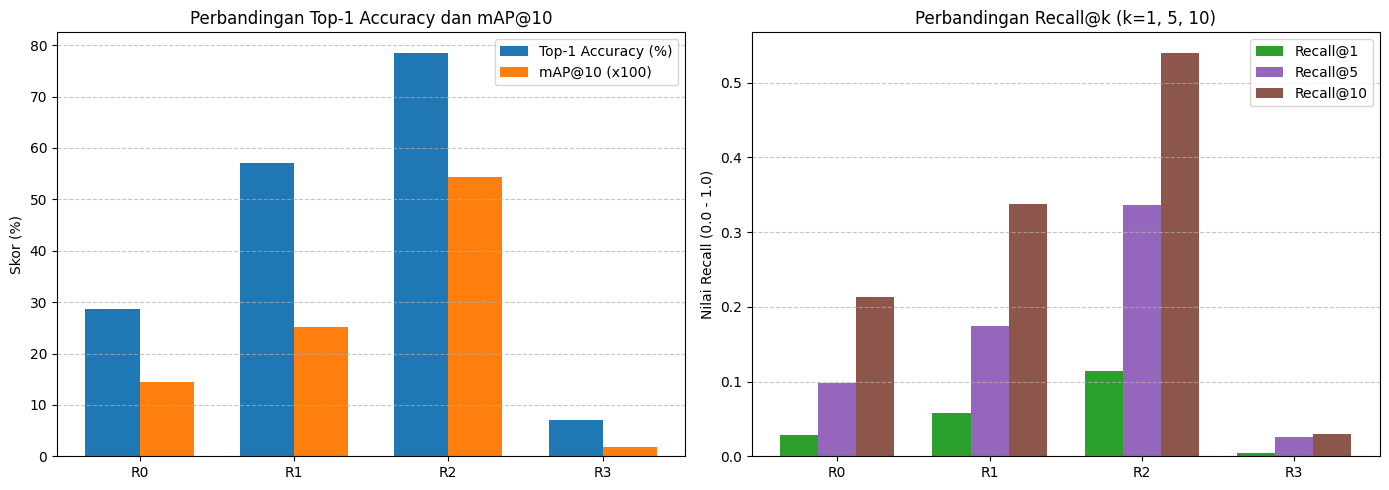

[SAVE] Grafik batang publikasi disimpan ke  : /content/drive/MyDrive/TUGAS AKHIR/results/figures/clean_retrieval_benchmark.png


In [29]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
labels = [r['representation'] for _, r in summary_df.iterrows()]
x = np.arange(len(labels))
width = 0.35
# Panel 1: Top-1 Accuracy & mAP@10
ax[0].bar(x - width/2, summary_df['Top1_Accuracy'], width, label='Top-1 Accuracy (%)', color='#1f77b4')
ax[0].bar(x + width/2, summary_df['mAP@10'] * 100, width, label='mAP@10 (x100)', color='#ff7f0e')
ax[0].set_ylabel('Skor (%)')
ax[0].set_title('Perbandingan Top-1 Accuracy dan mAP@10')
ax[0].set_xticks(x)
ax[0].set_xticklabels(labels)
ax[0].legend()
ax[0].grid(axis='y', linestyle='--', alpha=0.7)
# Panel 2: Recall Trajectory (R@1, R@5, R@10)
r_width = 0.25
ax[1].bar(x - r_width, summary_df['Recall@1'], r_width, label='Recall@1', color='#2ca02c')
ax[1].bar(x, summary_df['Recall@5'], r_width, label='Recall@5', color='#9467bd')
ax[1].bar(x + r_width, summary_df['Recall@10'], r_width, label='Recall@10', color='#8c564b')
ax[1].set_ylabel('Nilai Recall (0.0 - 1.0)')
ax[1].set_title('Perbandingan Recall@k (k=1, 5, 10)')
ax[1].set_xticks(x)
ax[1].set_xticklabels(labels)
ax[1].legend()
ax[1].grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
fig_path = os.path.join(results_fig_dir, "clean_retrieval_benchmark.png")
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"[SAVE] Grafik batang publikasi disimpan ke  : {fig_path}")

In [30]:
r3_map = summary_df[summary_df['representation']=='R3']['mAP@10'].values[0]
valid_e1 = all(summary_df[summary_df['representation']==c]['mAP@10'].values[0] > r3_map for c in ['R0', 'R1', 'R2'])
print("\n" + "=" * 85)
if valid_e1:
    print("[STATUS] TAHAP E1: SELESAI DAN VALID")
    print("  Seluruh artefak eksperimen E1 berhasil dibuat dan disimpan.")
else:
    print("[STATUS] TAHAP E1: PERLU PENINJAUAN")
print("=" * 85)


[STATUS] TAHAP E1: SELESAI DAN VALID
  Seluruh artefak eksperimen E1 berhasil dibuat dan disimpan.


In [31]:
import os
import zipfile
from google.colab import files

zip_name = 'hasil_e1_dan_preprocessing.zip'
base_drive = '/content/drive/MyDrive/TUGAS AKHIR'

files_to_pack = [
    'results/processed/clean_retrieval_table.csv',
    'results/processed/per_query_clean_retrieval.csv',
    'results/processed/preprocessing_verification_table.csv',
    'results/figures/clean_retrieval_benchmark.png',
    'results/figures/preprocessing_before_after_comparison.png'
]

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for rel_p in files_to_pack:
        full_p = os.path.join(base_drive, rel_p)
        if os.path.exists(full_p):
            zipf.write(full_p, rel_p)

print("[INFO] Mengunduh berkas hasil E1 ke laptop...")
files.download(zip_name)

[INFO] Mengunduh berkas hasil E1 ke laptop...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>